In [1]:
import os
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

def get_current_ram_gb():
    """Lấy lượng RAM hiện tại tiến trình Python đang chiếm dụng (GB)"""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def evaluate_models(file_path: str, n_splits: int = 5):
    print("=" * 85)
    print(f"📂 TEST DỮ LIỆU: {file_path}")
    print("=" * 85)

    if not os.path.exists(file_path):
        print(f"❌ Lỗi: Không tìm thấy file dữ liệu tại '{file_path}'")
        return

    df = pd.read_parquet(file_path) if file_path.endswith('.parquet') else pd.read_csv(file_path)

    n_rows, n_cols = df.shape
    dataset_ram_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    target_col = 'TARGET'
    ignore_cols = ['SK_ID_CURR', target_col]
    X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
    y = df[target_col]

    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    lgb_oof = np.zeros(len(X))
    xgb_oof = np.zeros(len(X))

    def calc_ks(y_true, y_pred):
        return ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic * 100

    # Danh sách lưu kết quả từng fold
    lgb_tr_aucs, lgb_va_aucs = [], []
    xgb_tr_aucs, xgb_va_aucs = [], []
    ens_tr_aucs, ens_va_aucs = [], []
    lgb_latencies, xgb_latencies = [], []

    lgb_params = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'learning_rate': 0.05, 'num_leaves': 31, 'random_state': 42,
        'n_jobs': -1, 'verbose': -1
    }
    xgb_params = {
        'objective': 'binary:logistic', 'eval_metric': 'auc', 'learning_rate': 0.05,
        'max_depth': 6, 'enable_categorical': True, 'tree_method': 'hist',
        'random_state': 42, 'n_jobs': -1
    }

    peak_ram_lgb = get_current_ram_gb()
    peak_ram_xgb = get_current_ram_gb()
    time_lgb_total = 0.0
    time_xgb_total = 0.0

    print(f"⚡ Đang chạy {n_splits}-Fold Cross Validation...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # --- 1. LightGBM ---
        t0_lgb = time.time()
        model_lgb = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
        model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
        time_lgb_total += (time.time() - t0_lgb)
        peak_ram_lgb = max(peak_ram_lgb, get_current_ram_gb())

        lgb_tr_pred = model_lgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        lgb_va_pred = model_lgb.predict_proba(X_va)[:, 1]
        lgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        lgb_oof[val_idx] = lgb_va_pred

        # --- 2. XGBoost ---
        t0_xgb = time.time()
        model_xgb = xgb.XGBClassifier(**xgb_params, n_estimators=1000, early_stopping_rounds=50)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        time_xgb_total += (time.time() - t0_xgb)
        peak_ram_xgb = max(peak_ram_xgb, get_current_ram_gb())

        xgb_tr_pred = model_xgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        xgb_va_pred = model_xgb.predict_proba(X_va)[:, 1]
        xgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        xgb_oof[val_idx] = xgb_va_pred

        # --- 3. Ensemble Fold ---
        ens_tr_pred = 0.5 * lgb_tr_pred + 0.5 * xgb_tr_pred
        ens_va_pred = 0.5 * lgb_va_pred + 0.5 * xgb_va_pred

        # Lưu AUC từng fold
        lgb_tr_auc = roc_auc_score(y_tr, lgb_tr_pred)
        lgb_va_auc = roc_auc_score(y_va, lgb_va_pred)
        lgb_tr_aucs.append(lgb_tr_auc)
        lgb_va_aucs.append(lgb_va_auc)

        xgb_tr_auc = roc_auc_score(y_tr, xgb_tr_pred)
        xgb_va_auc = roc_auc_score(y_va, xgb_va_pred)
        xgb_tr_aucs.append(xgb_tr_auc)
        xgb_va_aucs.append(xgb_va_auc)

        ens_tr_auc = roc_auc_score(y_tr, ens_tr_pred)
        ens_va_auc = roc_auc_score(y_va, ens_va_pred)
        ens_tr_aucs.append(ens_tr_auc)
        ens_va_aucs.append(ens_va_auc)

        # Tính Gap từng fold
        gap_lgb_f = lgb_tr_auc - lgb_va_auc
        gap_xgb_f = xgb_tr_auc - xgb_va_auc
        gap_ens_f = ens_tr_auc - ens_va_auc

        # IN LOG CHI TIẾT TỪNG FOLD KÈM THEO GAP
        print(f"   ▫️ Fold {fold} | LGB Val: {lgb_va_auc:.5f} (Gap: {gap_lgb_f:+.5f}) | XGB Val: {xgb_va_auc:.5f} (Gap: {gap_xgb_f:+.5f}) | Ens Val: {ens_va_auc:.5f} (Gap: {gap_ens_f:+.5f})")

    # --- 🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG ---
    ensemble_oof = 0.5 * lgb_oof + 0.5 * xgb_oof
    lgb_auc = roc_auc_score(y, lgb_oof)
    xgb_auc = roc_auc_score(y, xgb_oof)
    ens_auc = roc_auc_score(y, ensemble_oof)

    print("\n" + "=" * 60)
    print("🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG")
    print("=" * 60)
    print(f"🔹 LightGBM : {lgb_auc:.5f}")
    print(f"🔹 XGBoost  : {xgb_auc:.5f}")
    print(f"🥇 Ensemble : {ens_auc:.5f}")
    print("=" * 60)

    # Tính mảng Gap
    lgb_gaps = np.array(lgb_tr_aucs) - np.array(lgb_va_aucs)
    xgb_gaps = np.array(xgb_tr_aucs) - np.array(xgb_va_aucs)
    ens_gaps = np.array(ens_tr_aucs) - np.array(ens_va_aucs)

    models_eval = [
        ('LightGBM', lgb_auc, lgb_tr_aucs, lgb_va_aucs, lgb_gaps, lgb_oof, time_lgb_total, peak_ram_lgb, np.mean(lgb_latencies)),
        ('XGBoost', xgb_auc, xgb_tr_aucs, xgb_va_aucs, xgb_gaps, xgb_oof, time_xgb_total, peak_ram_xgb, np.mean(xgb_latencies)),
        ('Ensemble (50/50)', ens_auc, ens_tr_aucs, ens_va_aucs, ens_gaps, ensemble_oof, time_lgb_total + time_xgb_total, max(peak_ram_lgb, peak_ram_xgb), np.mean(lgb_latencies) + np.mean(xgb_latencies))
    ]

    perf_records = []
    res_records = []

    for name, main_auc, tr_list, va_list, gaps, oof_preds, t_run, p_ram, lat in models_eval:
        mean_tr = np.mean(tr_list)
        mean_va = np.mean(va_list)
        brier = brier_score_loss(y, oof_preds)

        perf_records.append({
            'Model': name,
            'ROC-AUC': f"{main_auc:.5f}",
            'Fold AUC (Mean ± Std)': f"{mean_va:.5f} ± {np.std(va_list):.5f}",
            'Train AUC': f"{mean_tr:.5f}",
            'Gap (Mean ± Std)': f"{np.mean(gaps):.5f} ± {np.std(gaps):.5f}",
            'Gini (%)': f"{(2 * main_auc - 1) * 100:.2f}%",
            'KS (%)': f"{calc_ks(y, oof_preds):.2f}%",
            'Brier Score': f"{brier:.5f}"
        })

        res_records.append({
            'Model': name,
            'Training Time': f"{t_run:.1f} s",
            'Peak RAM': f"{p_ram:.2f} GB",
            'Inference Latency': f"{lat:.4f} ms/sample"
        })

    # --- BẢNG 1: HIỆU NĂNG & CHỈ SỐ TÍN DỤNG ---
    print("\n📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)")
    display(pd.DataFrame(perf_records))

    # --- BẢNG 2: TIÊU HAO TÀI NGUYÊN & THÔNG SỐ DỮ LIỆU ---
    print("\n⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)")
    display(pd.DataFrame(res_records))

    # Đưa thông số cấu hình dữ liệu xuống ngay dưới Bảng 2
    print(f"📌 Thông số tập dữ liệu: {n_rows:,} dòng | {X.shape[1]} đặc trưng (cột) | Dung lượng trên RAM: {dataset_ram_mb:.1f} MB")

    # --- VẼ CALIBRATION CURVE (CHỈ DISPLAY TRỰC TIẾP TRÊN NOTEBOOK) ---
    print("\n📈 Đang hiển thị biểu đồ Calibration Curve...")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Mô hình hoàn hảo (Perfect Calibration)')

    colors = {
        'LightGBM': '#1f77b4',
        'XGBoost': '#ff7f0e',
        'Ensemble (50/50)': '#2ca02c'
    }

    for name, _, _, _, _, oof_preds, _, _, _ in models_eval:
        prob_true, prob_pred = calibration_curve(y, oof_preds, n_bins=10, strategy='quantile')
        b_val = brier_score_loss(y, oof_preds)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, color=colors[name],
                label=f'{name} (Brier: {b_val:.4f})')

    ax.set_xlabel('Xác suất vỡ nợ dự báo (Mean Predicted PD)', fontsize=11)
    ax.set_ylabel('Tỷ lệ nợ xấu thực tế (Fraction of Positives)', fontsize=11)
    ax.set_title('Đường Cong Chuẩn Hóa Xác Suất (Calibration Curve - Baseline)', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [20]:
import os
import time
import json
import psutil
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

def get_current_ram_gb():
    """Lấy lượng RAM hiện tại tiến trình Python đang chiếm dụng (GB)"""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def calc_ks(y_true, y_pred):
    """Tính toán chỉ số Kolmogorov-Smirnov (KS)"""
    return ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic * 100

def evaluate_models_v2_optimized(
    file_path: str,
    n_splits: int = 5,
    save_models: bool = True,
    artifact_dir: str = "/Users/nguyenminhtri/FinalYearPro/notebook/Model/fair"
):
    print("=" * 95)
    print(f"📂 [V2 OPTIMIZED] ĐÁNH GIÁ MÔ HÌNH VỚI BEST HYPERPARAMETERS: {file_path}")
    print("=" * 95)

    if not os.path.exists(file_path):
        print(f"❌ Lỗi: Không tìm thấy file dữ liệu tại '{file_path}'")
        return

    # Tạo đầy đủ thư mục cha nếu chưa tồn tại
    if save_models:
        os.makedirs(artifact_dir, exist_ok=True)

    df = pd.read_parquet(file_path) if file_path.endswith('.parquet') else pd.read_csv(file_path)

    n_rows, n_cols = df.shape
    dataset_ram_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    target_col = 'TARGET'
    ignore_cols = ['SK_ID_CURR', target_col]
    X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
    y = df[target_col].values

    # Chuẩn hóa biến Categorical cho GBDT
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')

    # =========================================================================
    # 1. CẤU HÌNH THAM SỐ ĐÃ QUA TUNING (OPTUNA BEST TRIALS)
    # =========================================================================
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': 0.0218,
        'num_leaves': 54,
        'max_depth': 7,
        'min_child_samples': 87,
        'colsample_bytree': 0.6048,
        'subsample': 0.8906,
        'subsample_freq': 1,
        'reg_alpha': 5.7108,
        'reg_lambda': 0.0581,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'enable_categorical': True,
        'learning_rate': 0.0245,
        'max_depth': 9,
        'min_child_weight': 160,
        'colsample_bytree': 0.8349,
        'subsample': 0.9237,
        'reg_alpha': 0.6219,
        'reg_lambda': 5.8294,
        'random_state': 42,
        'n_jobs': -1
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    lgb_oof = np.zeros(len(X))
    xgb_oof = np.zeros(len(X))

    lgb_tr_aucs, lgb_va_aucs = [], []
    xgb_tr_aucs, xgb_va_aucs = [], []
    lgb_latencies, xgb_latencies = [], []

    trained_lgb_models = []
    trained_xgb_models = []

    peak_ram_lgb = get_current_ram_gb()
    peak_ram_xgb = get_current_ram_gb()
    time_lgb_total = 0.0
    time_xgb_total = 0.0

    print(f"⚡ Đang chạy {n_splits}-Fold Cross Validation (Phiên bản V2 Tối Ưu)...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[train_idx], y[train_idx]
        X_va, y_va = X.iloc[val_idx], y[val_idx]

        # --- 2. Huấn luyện LightGBM ---
        t0_lgb = time.time()
        model_lgb = lgb.LGBMClassifier(**lgb_params, n_estimators=3000)
        model_lgb.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=60, verbose=False)]
        )
        time_lgb_total += (time.time() - t0_lgb)
        peak_ram_lgb = max(peak_ram_lgb, get_current_ram_gb())

        lgb_tr_pred = model_lgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        lgb_va_pred = model_lgb.predict_proba(X_va)[:, 1]
        lgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        lgb_oof[val_idx] = lgb_va_pred

        if save_models:
            joblib.dump(model_lgb, os.path.join(artifact_dir, f"lgb_model_fold_{fold}.joblib"))
        trained_lgb_models.append(model_lgb)

        # --- 3. Huấn luyện XGBoost ---
        t0_xgb = time.time()
        model_xgb = xgb.XGBClassifier(**xgb_params, n_estimators=3000, early_stopping_rounds=60)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        time_xgb_total += (time.time() - t0_xgb)
        peak_ram_xgb = max(peak_ram_xgb, get_current_ram_gb())

        xgb_tr_pred = model_xgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        xgb_va_pred = model_xgb.predict_proba(X_va)[:, 1]
        xgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        xgb_oof[val_idx] = xgb_va_pred

        if save_models:
            joblib.dump(model_xgb, os.path.join(artifact_dir, f"xgb_model_fold_{fold}.joblib"))
        trained_xgb_models.append(model_xgb)

        # --- 4. Ghi nhận metric từng Fold ---
        lgb_tr_auc = roc_auc_score(y_tr, lgb_tr_pred)
        lgb_va_auc = roc_auc_score(y_va, lgb_va_pred)
        lgb_tr_aucs.append(lgb_tr_auc)
        lgb_va_aucs.append(lgb_va_auc)

        xgb_tr_auc = roc_auc_score(y_tr, xgb_tr_pred)
        xgb_va_auc = roc_auc_score(y_va, xgb_va_pred)
        xgb_tr_aucs.append(xgb_tr_auc)
        xgb_va_aucs.append(xgb_va_auc)

        print(f"   ▫️ Fold {fold} | LGB Val: {lgb_va_auc:.5f} (Gap: {lgb_tr_auc - lgb_va_auc:+.5f}) | XGB Val: {xgb_va_auc:.5f} (Gap: {xgb_tr_auc - xgb_va_auc:+.5f})")

    # =========================================================================
    # 5. TỐI ƯU TRỌNG SỐ BLENDING DỰA TRÊN TOÀN BỘ OUT-OF-FOLD (OOF)
    # =========================================================================
    def loss_func(w):
        blend = w[0] * lgb_oof + (1 - w[0]) * xgb_oof
        return -roc_auc_score(y, blend)

    res = minimize(loss_func, [0.5], bounds=[(0.0, 1.0)], method='SLSQP')
    w_lgb = float(res.x[0])
    w_xgb = 1.0 - w_lgb

    opt_ensemble_oof = w_lgb * lgb_oof + w_xgb * xgb_oof

    ens_tr_aucs = []
    ens_va_aucs = []
    for f in range(n_splits):
        tr_pred_ens = w_lgb * lgb_tr_aucs[f] + w_xgb * xgb_tr_aucs[f]
        va_pred_ens = w_lgb * lgb_va_aucs[f] + w_xgb * xgb_va_aucs[f]
        ens_tr_aucs.append(tr_pred_ens)
        ens_va_aucs.append(va_pred_ens)

    lgb_auc = roc_auc_score(y, lgb_oof)
    xgb_auc = roc_auc_score(y, xgb_oof)
    opt_ens_auc = roc_auc_score(y, opt_ensemble_oof)

    print("\n" + "=" * 65)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC V2 (OOF ROC-AUC)")
    print("=" * 65)
    print(f"🔹 LightGBM (Tuned)    : {lgb_auc:.5f}")
    print(f"🔹 XGBoost (Tuned)     : {xgb_auc:.5f}")
    print(f"🥇 Optimal Blend       : {opt_ens_auc:.5f}")
    print(f"⚖️ Trọng số tối ưu     : LightGBM = {w_lgb*100:.1f}% | XGBoost = {w_xgb*100:.1f}%")
    print("=" * 65)

    # =========================================================================
    # 6. HIỂN THỊ BẢNG ĐỐI CHỨNG (TÍCH HỢP BRIER SCORE)
    # =========================================================================
    lgb_gaps = np.array(lgb_tr_aucs) - np.array(lgb_va_aucs)
    xgb_gaps = np.array(xgb_tr_aucs) - np.array(xgb_va_aucs)
    ens_gaps = np.array(ens_tr_aucs) - np.array(ens_va_aucs)

    models_eval = [
        ('LightGBM (Tuned)', lgb_auc, lgb_tr_aucs, lgb_va_aucs, lgb_gaps, lgb_oof, time_lgb_total, peak_ram_lgb, np.mean(lgb_latencies)),
        ('XGBoost (Tuned)', xgb_auc, xgb_tr_aucs, xgb_va_aucs, xgb_gaps, xgb_oof, time_xgb_total, peak_ram_xgb, np.mean(xgb_latencies)),
        (f'Optimal Blend ({w_lgb:.2f}/{w_xgb:.2f})', opt_ens_auc, ens_tr_aucs, ens_va_aucs, ens_gaps, opt_ensemble_oof, time_lgb_total + time_xgb_total, max(peak_ram_lgb, peak_ram_xgb), np.mean(lgb_latencies) + np.mean(xgb_latencies))
    ]

    perf_records = []
    res_records = []

    for name, main_auc, tr_list, va_list, gaps, oof_preds, t_run, p_ram, lat in models_eval:
        brier = brier_score_loss(y, oof_preds)

        perf_records.append({
            'Model': name,
            'ROC-AUC (OOF)': f"{main_auc:.5f}",
            'Fold AUC (Mean ± Std)': f"{np.mean(va_list):.5f} ± {np.std(va_list):.5f}",
            'Train AUC': f"{np.mean(tr_list):.5f}",
            'Overfit Gap': f"{np.mean(gaps):.5f} ± {np.std(gaps):.5f}",
            'Gini (%)': f"{(2 * main_auc - 1) * 100:.2f}%",
            'KS (%)': f"{calc_ks(y, oof_preds):.2f}%",
            'Brier Score': f"{brier:.5f}"
        })

        res_records.append({
            'Model': name,
            'Training Time': f"{t_run:.1f} s",
            'Peak RAM': f"{p_ram:.2f} GB",
            'Inference Latency': f"{lat:.4f} ms/sample"
        })

    print("\n📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG & ĐỘ CHUẨN XÁC XÁC SUẤT (V2 OPTIMIZED)")
    display(pd.DataFrame(perf_records))

    print("\n⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (V2 OPTIMIZED)")
    display(pd.DataFrame(res_records))

    print(f"\n📌 Thông số tập dữ liệu: {n_rows:,} dòng | {X.shape[1]} đặc trưng | RAM: {dataset_ram_mb:.1f} MB")

    # =========================================================================
    # 7. TRỰC QUAN HÓA CALIBRATION CURVE (CHỈ HIỂN THỊ NOTEBOOK)
    # =========================================================================
    print("\n📈 Đang hiển thị biểu đồ Calibration Curve...")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Mô hình hoàn hảo (Perfect Calibration)')

    colors = {
        'LightGBM (Tuned)': '#1f77b4',
        'XGBoost (Tuned)': '#ff7f0e',
        f'Optimal Blend ({w_lgb:.2f}/{w_xgb:.2f})': '#2ca02c'
    }

    for name, _, _, _, _, oof_preds, _, _, _ in models_eval:
        prob_true, prob_pred = calibration_curve(y, oof_preds, n_bins=10, strategy='quantile')
        b_val = brier_score_loss(y, oof_preds)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, color=colors[name],
                label=f'{name} (Brier: {b_val:.4f})')

    ax.set_xlabel('Xác suất vỡ nợ dự báo (Mean Predicted PD)', fontsize=11)
    ax.set_ylabel('Tỷ lệ nợ xấu thực tế (Fraction of Positives)', fontsize=11)
    ax.set_title('Đường Cong Chuẩn Hóa Xác Suất (Calibration Curve - V2 Tuned)', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Lưu metadata cấu hình
    blend_config = {
        'best_weight_lgb': w_lgb,
        'best_weight_xgb': w_xgb,
        'ensemble_auc': opt_ens_auc,
        'feature_names': list(X.columns)
    }
    with open(os.path.join(artifact_dir, "blend_config_v2.json"), "w") as f:
        json.dump(blend_config, f, indent=4)

    print(f"💾 Đã lưu cấu hình Ensemble & 10 Models vào: '{artifact_dir}'")

    return {
        'lgb_models': trained_lgb_models,
        'xgb_models': trained_xgb_models,
        'weights': (w_lgb, w_xgb),
        'oof_predictions': opt_ensemble_oof,
        'y_true': y,
        'lgb_oof': lgb_oof,
        'xgb_oof': xgb_oof
    }

📂 TEST DỮ LIỆU: ../../data/processed/df_main_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.75086 (Gap: +0.04189) | XGB Val: 0.75136 (Gap: +0.05840) | Ens Val: 0.75207 (Gap: +0.05138)
   ▫️ Fold 2 | LGB Val: 0.75817 (Gap: +0.06126) | XGB Val: 0.75776 (Gap: +0.05702) | Ens Val: 0.75914 (Gap: +0.06081)
   ▫️ Fold 3 | LGB Val: 0.74984 (Gap: +0.05388) | XGB Val: 0.74834 (Gap: +0.06122) | Ens Val: 0.75003 (Gap: +0.05889)
   ▫️ Fold 4 | LGB Val: 0.75786 (Gap: +0.06072) | XGB Val: 0.75666 (Gap: +0.05273) | Ens Val: 0.75831 (Gap: +0.05886)
   ▫️ Fold 5 | LGB Val: 0.74818 (Gap: +0.04943) | XGB Val: 0.74908 (Gap: +0.07144) | Ens Val: 0.74980 (Gap: +0.06219)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.75299
🔹 XGBoost  : 0.75261
🥇 Ensemble : 0.75387

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.75299,0.75298 ± 0.00420,0.80642,0.05344 ± 0.00726,50.60%,37.60%,0.06814
1,XGBoost,0.75261,0.75264 ± 0.00388,0.81280,0.06016 ± 0.00627,50.52%,37.49%,0.06816
2,Ensemble (50/50),0.75387,0.75387 ± 0.00405,0.81230,0.05842 ± 0.00374,50.77%,37.66%,0.06808



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,16.8 s,0.91 GB,0.0022 ms/sample
1,XGBoost,36.0 s,0.91 GB,0.0010 ms/sample
2,Ensemble (50/50),52.8 s,0.91 GB,0.0032 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 21 đặc trưng (cột) | Dung lượng trên RAM: 74.2 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


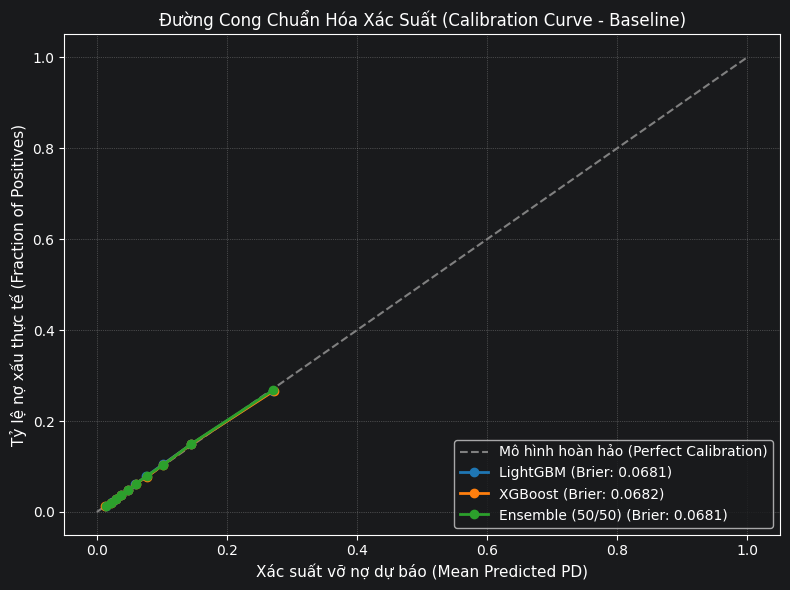

In [3]:

evaluate_models('../data/preprocess/df_main_clean.parquet')

📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/table/df_main_clean_fe.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.76027 (Gap: +0.06312) | XGB Val: 0.75934 (Gap: +0.07816) | Ens Val: 0.76130 (Gap: +0.07265)
   ▫️ Fold 2 | LGB Val: 0.76880 (Gap: +0.07203) | XGB Val: 0.76862 (Gap: +0.05838) | Ens Val: 0.77005 (Gap: +0.06816)
   ▫️ Fold 3 | LGB Val: 0.75849 (Gap: +0.08690) | XGB Val: 0.75703 (Gap: +0.05882) | Ens Val: 0.75909 (Gap: +0.07691)
   ▫️ Fold 4 | LGB Val: 0.76504 (Gap: +0.04958) | XGB Val: 0.76484 (Gap: +0.06961) | Ens Val: 0.76643 (Gap: +0.06139)
   ▫️ Fold 5 | LGB Val: 0.75850 (Gap: +0.07088) | XGB Val: 0.75971 (Gap: +0.07389) | Ens Val: 0.76035 (Gap: +0.07416)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.76220
🔹 XGBoost  : 0.76189
🥇 Ensemble : 0.76343

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.76220,0.76222 ± 0.00407,0.83072,0.06850 ± 0.01219,52.44%,38.96%,0.06768
1,XGBoost,0.76189,0.76191 ± 0.00422,0.82968,0.06777 ± 0.00796,52.38%,38.77%,0.06769
2,Ensemble (50/50),0.76343,0.76344 ± 0.00414,0.83410,0.07065 ± 0.00543,52.69%,39.10%,0.06759



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,23.3 s,1.19 GB,0.0023 ms/sample
1,XGBoost,46.2 s,1.17 GB,0.0009 ms/sample
2,Ensemble (50/50),69.5 s,1.19 GB,0.0032 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 45 đặc trưng (cột) | Dung lượng trên RAM: 130.6 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


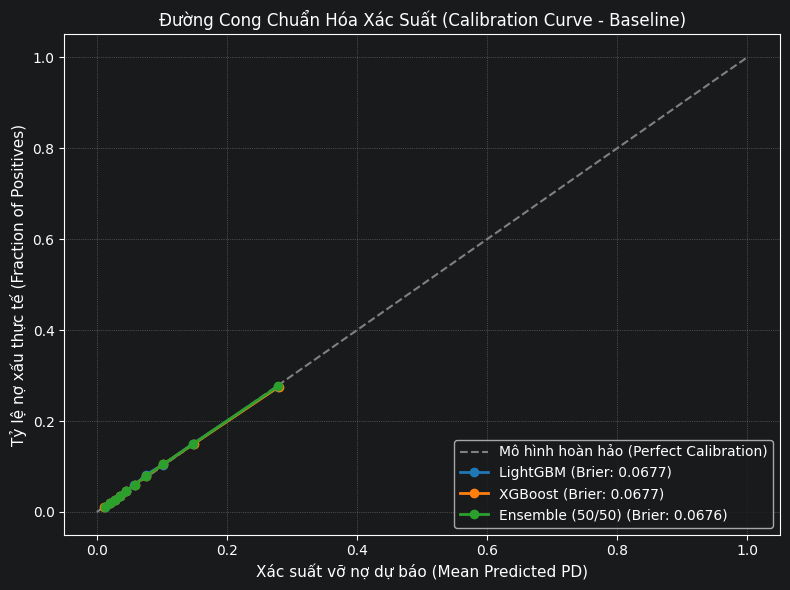

In [4]:
evaluate_models('/data/preprocess/table/df_main_clean_fe.parquet')

📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.77150 (Gap: +0.06585) | XGB Val: 0.77116 (Gap: +0.08967) | Ens Val: 0.77284 (Gap: +0.07998)
   ▫️ Fold 2 | LGB Val: 0.77909 (Gap: +0.08931) | XGB Val: 0.77812 (Gap: +0.08923) | Ens Val: 0.78042 (Gap: +0.09167)
   ▫️ Fold 3 | LGB Val: 0.76926 (Gap: +0.06685) | XGB Val: 0.77018 (Gap: +0.08626) | Ens Val: 0.77109 (Gap: +0.07894)
   ▫️ Fold 4 | LGB Val: 0.77857 (Gap: +0.06454) | XGB Val: 0.77800 (Gap: +0.08769) | Ens Val: 0.77991 (Gap: +0.07858)
   ▫️ Fold 5 | LGB Val: 0.76974 (Gap: +0.10369) | XGB Val: 0.76988 (Gap: +0.10670) | Ens Val: 0.77152 (Gap: +0.10758)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.77357
🔹 XGBoost  : 0.77344
🥇 Ensemble : 0.77512

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.77357,0.77363 ± 0.00431,0.85168,0.07805 ± 0.01576,54.71%,40.54%,0.06693
1,XGBoost,0.77344,0.77347 ± 0.00377,0.86538,0.09191 ± 0.00749,54.69%,40.85%,0.06690
2,Ensemble (50/50),0.77512,0.77516 ± 0.00413,0.86250,0.08735 ± 0.01122,55.02%,40.93%,0.06679



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,63.4 s,3.82 GB,0.0029 ms/sample
1,XGBoost,297.4 s,2.44 GB,0.0017 ms/sample
2,Ensemble (50/50),360.8 s,3.82 GB,0.0046 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 417 đặc trưng (cột) | Dung lượng trên RAM: 1003.3 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


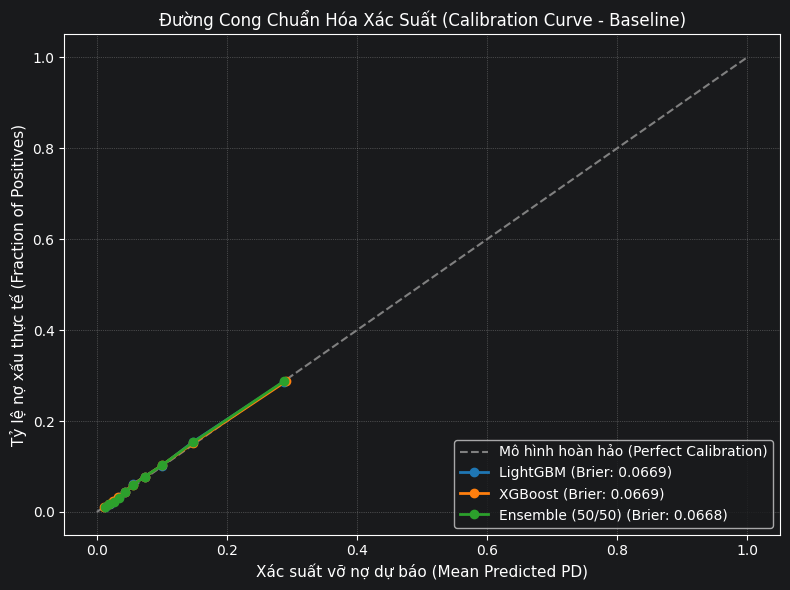

In [5]:
evaluate_models('/data/processed/df_main_x_bureau.parquet')

📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_all.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.77141 (Gap: +0.09766) | XGB Val: 0.77074 (Gap: +0.10490) | Ens Val: 0.77284 (Gap: +0.10363)
   ▫️ Fold 2 | LGB Val: 0.77825 (Gap: +0.07558) | XGB Val: 0.77821 (Gap: +0.07265) | Ens Val: 0.77967 (Gap: +0.07611)
   ▫️ Fold 3 | LGB Val: 0.76995 (Gap: +0.08172) | XGB Val: 0.77009 (Gap: +0.10733) | Ens Val: 0.77161 (Gap: +0.09723)
   ▫️ Fold 4 | LGB Val: 0.77798 (Gap: +0.06123) | XGB Val: 0.77784 (Gap: +0.10608) | Ens Val: 0.77988 (Gap: +0.08833)
   ▫️ Fold 5 | LGB Val: 0.76909 (Gap: +0.09449) | XGB Val: 0.77109 (Gap: +0.11267) | Ens Val: 0.77181 (Gap: +0.10616)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.77327
🔹 XGBoost  : 0.77353
🥇 Ensemble : 0.77511

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.77327,0.77333 ± 0.00397,0.85547,0.08214 ± 0.01322,54.65%,40.66%,0.06693
1,XGBoost,0.77353,0.77359 ± 0.00363,0.87432,0.10073 ± 0.01429,54.71%,40.79%,0.06693
2,Ensemble (50/50),0.77511,0.77516 ± 0.00379,0.86946,0.09429 ± 0.01098,55.02%,40.91%,0.06680



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,78.8 s,3.73 GB,0.0034 ms/sample
1,XGBoost,438.0 s,2.55 GB,0.0024 ms/sample
2,Ensemble (50/50),516.9 s,3.73 GB,0.0058 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 496 đặc trưng (cột) | Dung lượng trên RAM: 1188.7 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


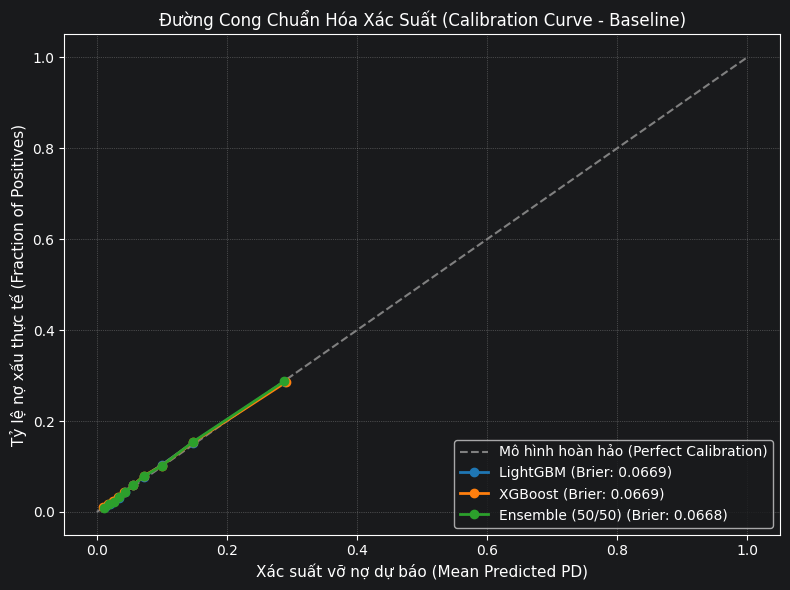

In [6]:
evaluate_models('/data/processed/df_main_x_bureau_all.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.77992 (Gap: +0.09975) | XGB Val: 0.78060 (Gap: +0.10159) | Ens Val: 0.78190 (Gap: +0.10288)
   ▫️ Fold 2 | LGB Val: 0.78834 (Gap: +0.06191) | XGB Val: 0.79119 (Gap: +0.12300) | Ens Val: 0.79231 (Gap: +0.09986)
   ▫️ Fold 3 | LGB Val: 0.77804 (Gap: +0.10723) | XGB Val: 0.77710 (Gap: +0.10272) | Ens Val: 0.77906 (Gap: +0.10762)
   ▫️ Fold 4 | LGB Val: 0.78827 (Gap: +0.09608) | XGB Val: 0.78706 (Gap: +0.11679) | Ens Val: 0.78973 (Gap: +0.10881)
   ▫️ Fold 5 | LGB Val: 0.77868 (Gap: +0.12441) | XGB Val: 0.78006 (Gap: +0.13245) | Ens Val: 0.78136 (Gap: +0.13073)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78254
🔹 XGBoost  : 0.78319
🥇 Ensemble : 0.78483

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78254,0.78265 ± 0.00466,0.88053,0.09788 ± 0.02045,56.51%,42.42%,0.06631
1,XGBoost,0.78319,0.78320 ± 0.00515,0.89852,0.11531 ± 0.01185,56.64%,42.61%,0.06621
2,Ensemble (50/50),0.78483,0.78487 ± 0.00518,0.89485,0.10998 ± 0.01086,56.97%,42.75%,0.06610



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,182.1 s,3.45 GB,0.0057 ms/sample
1,XGBoost,1056.5 s,3.45 GB,0.0041 ms/sample
2,Ensemble (50/50),1238.6 s,3.45 GB,0.0098 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1089 đặc trưng (cột) | Dung lượng trên RAM: 2579.9 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


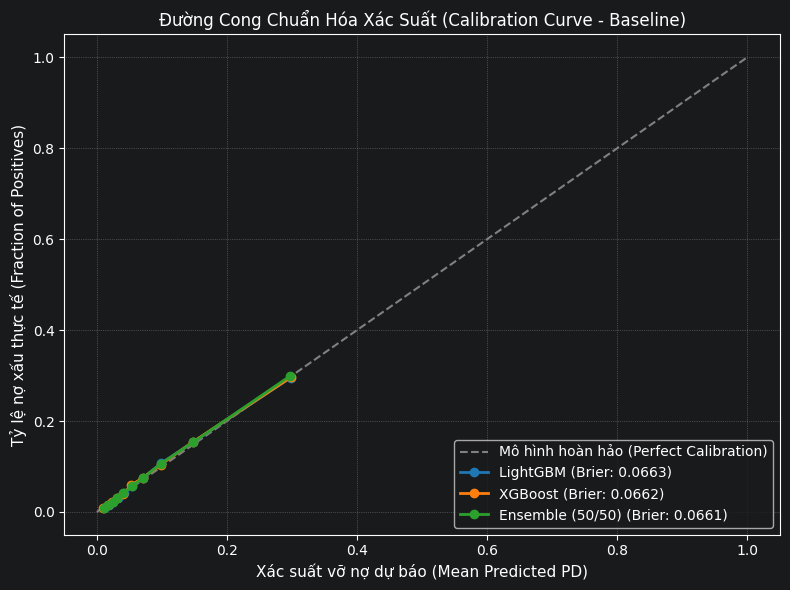

In [7]:
evaluate_models('/data/processed/df_main_x_bureau_x_prev.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev_x_pos.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78166 (Gap: +0.09964) | XGB Val: 0.78298 (Gap: +0.12299) | Ens Val: 0.78431 (Gap: +0.11407)
   ▫️ Fold 2 | LGB Val: 0.79185 (Gap: +0.07776) | XGB Val: 0.79323 (Gap: +0.12060) | Ens Val: 0.79480 (Gap: +0.10380)
   ▫️ Fold 3 | LGB Val: 0.77904 (Gap: +0.08453) | XGB Val: 0.77885 (Gap: +0.11183) | Ens Val: 0.78058 (Gap: +0.10105)
   ▫️ Fold 4 | LGB Val: 0.78906 (Gap: +0.07643) | XGB Val: 0.78884 (Gap: +0.11222) | Ens Val: 0.79086 (Gap: +0.09811)
   ▫️ Fold 5 | LGB Val: 0.78034 (Gap: +0.10381) | XGB Val: 0.78123 (Gap: +0.11095) | Ens Val: 0.78249 (Gap: +0.10978)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78435
🔹 XGBoost  : 0.78503
🥇 Ensemble : 0.78659

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78435,0.78439 ± 0.00510,0.87283,0.08843 ± 0.01127,56.87%,42.89%,0.06611
1,XGBoost,0.78503,0.78503 ± 0.00526,0.90074,0.11572 ± 0.00504,57.01%,43.02%,0.06606
2,Ensemble (50/50),0.78659,0.78661 ± 0.00536,0.89197,0.10536 ± 0.00581,57.32%,43.38%,0.06593



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,184.8 s,2.53 GB,0.0057 ms/sample
1,XGBoost,1132.9 s,2.53 GB,0.0045 ms/sample
2,Ensemble (50/50),1317.7 s,2.53 GB,0.0103 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1183 đặc trưng (cột) | Dung lượng trên RAM: 2800.4 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


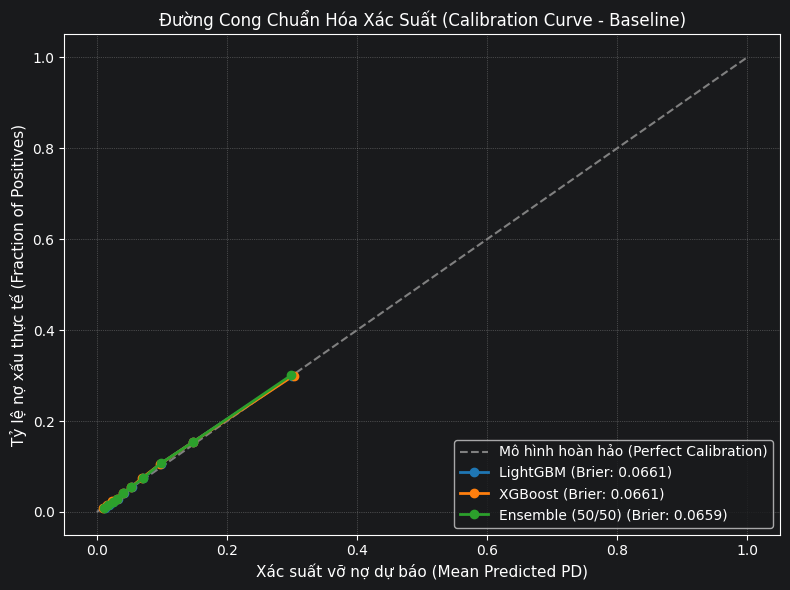

In [8]:
evaluate_models('/data/processed/df_main_x_bureau_x_prev_x_pos.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev_x_pos_x_ins.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78461 (Gap: +0.07052) | XGB Val: 0.78571 (Gap: +0.10722) | Ens Val: 0.78681 (Gap: +0.09263)
   ▫️ Fold 2 | LGB Val: 0.79413 (Gap: +0.08710) | XGB Val: 0.79646 (Gap: +0.10872) | Ens Val: 0.79728 (Gap: +0.10054)
   ▫️ Fold 3 | LGB Val: 0.78342 (Gap: +0.09326) | XGB Val: 0.78305 (Gap: +0.10515) | Ens Val: 0.78484 (Gap: +0.10138)
   ▫️ Fold 4 | LGB Val: 0.79197 (Gap: +0.09416) | XGB Val: 0.79170 (Gap: +0.10674) | Ens Val: 0.79366 (Gap: +0.10262)
   ▫️ Fold 5 | LGB Val: 0.78379 (Gap: +0.09011) | XGB Val: 0.78533 (Gap: +0.13431) | Ens Val: 0.78660 (Gap: +0.11726)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78757
🔹 XGBoost  : 0.78840
🥇 Ensemble : 0.78982

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78757,0.78758 ± 0.00453,0.87461,0.08703 ± 0.00862,57.51%,43.52%,0.06593
1,XGBoost,0.78840,0.78845 ± 0.00492,0.90088,0.11243 ± 0.01100,57.68%,43.49%,0.06585
2,Ensemble (50/50),0.78982,0.78984 ± 0.00479,0.89272,0.10289 ± 0.00799,57.96%,43.88%,0.06573



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,195.5 s,3.30 GB,0.0057 ms/sample
1,XGBoost,1105.9 s,3.30 GB,0.0043 ms/sample
2,Ensemble (50/50),1301.4 s,3.30 GB,0.0100 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1235 đặc trưng (cột) | Dung lượng trên RAM: 2922.4 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


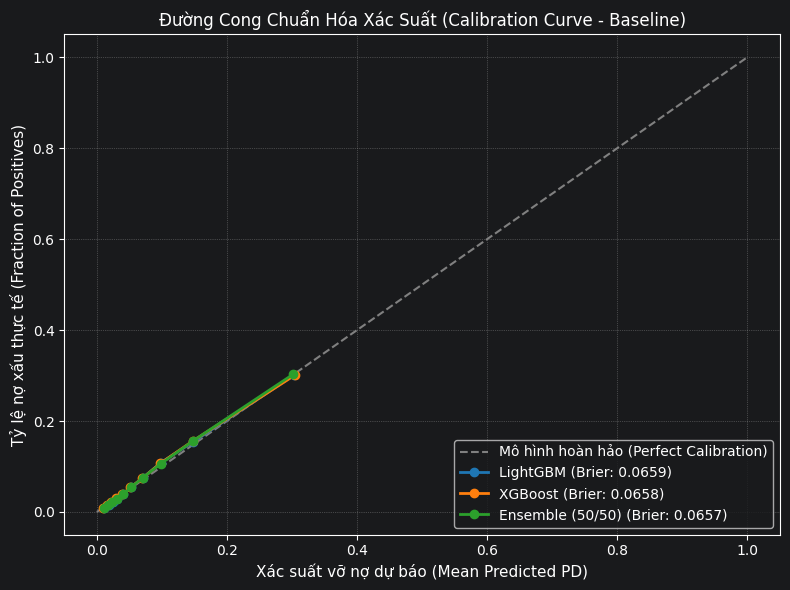

In [9]:
evaluate_models('/data/processed/df_main_x_bureau_x_prev_x_pos_x_ins.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78688 (Gap: +0.08014) | XGB Val: 0.78698 (Gap: +0.12059) | Ens Val: 0.78886 (Gap: +0.10444)
   ▫️ Fold 2 | LGB Val: 0.79478 (Gap: +0.08588) | XGB Val: 0.79680 (Gap: +0.09783) | Ens Val: 0.79747 (Gap: +0.09405)
   ▫️ Fold 3 | LGB Val: 0.78524 (Gap: +0.09914) | XGB Val: 0.78446 (Gap: +0.12967) | Ens Val: 0.78692 (Gap: +0.11742)
   ▫️ Fold 4 | LGB Val: 0.79306 (Gap: +0.09567) | XGB Val: 0.79290 (Gap: +0.10296) | Ens Val: 0.79471 (Gap: +0.10133)
   ▫️ Fold 5 | LGB Val: 0.78477 (Gap: +0.07325) | XGB Val: 0.78623 (Gap: +0.12419) | Ens Val: 0.78739 (Gap: +0.10448)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78894
🔹 XGBoost  : 0.78941
🥇 Ensemble : 0.79104

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78894,0.78895 ± 0.00416,0.87576,0.08682 ± 0.00959,57.79%,43.60%,0.06583
1,XGBoost,0.78941,0.78947 ± 0.00463,0.90452,0.11505 ± 0.01241,57.88%,43.79%,0.06575
2,Ensemble (50/50),0.79104,0.79107 ± 0.00424,0.89541,0.10434 ± 0.00756,58.21%,44.08%,0.06563



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,222.1 s,3.69 GB,0.0061 ms/sample
1,XGBoost,1298.6 s,3.69 GB,0.0053 ms/sample
2,Ensemble (50/50),1520.7 s,3.69 GB,0.0114 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1378 đặc trưng (cột) | Dung lượng trên RAM: 3257.9 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


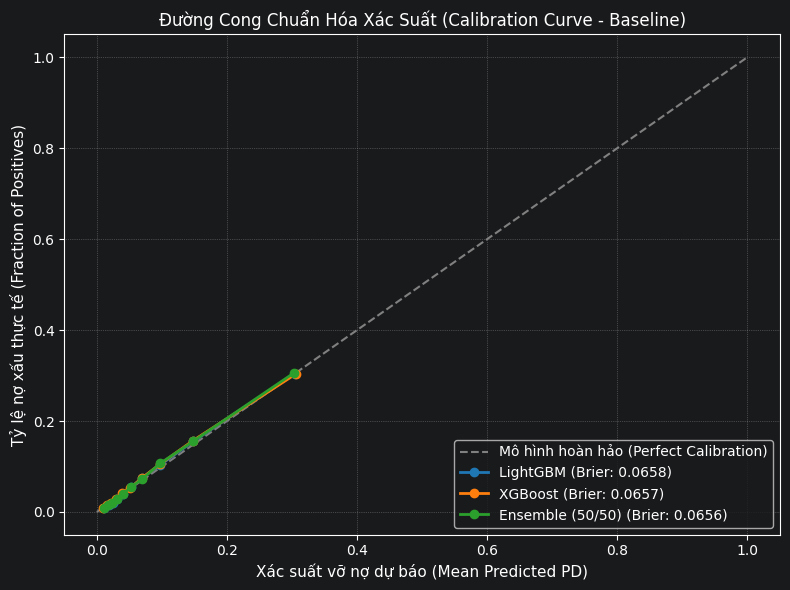

In [10]:
evaluate_models('/data/processed/master_train_dataset.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v2.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78660 (Gap: +0.08124) | XGB Val: 0.78670 (Gap: +0.10148) | Ens Val: 0.78823 (Gap: +0.09370)
   ▫️ Fold 2 | LGB Val: 0.79437 (Gap: +0.05635) | XGB Val: 0.79579 (Gap: +0.10104) | Ens Val: 0.79698 (Gap: +0.08314)
   ▫️ Fold 3 | LGB Val: 0.78453 (Gap: +0.08044) | XGB Val: 0.78440 (Gap: +0.09921) | Ens Val: 0.78599 (Gap: +0.09179)
   ▫️ Fold 4 | LGB Val: 0.79302 (Gap: +0.07033) | XGB Val: 0.79269 (Gap: +0.10172) | Ens Val: 0.79453 (Gap: +0.08923)
   ▫️ Fold 5 | LGB Val: 0.78447 (Gap: +0.10338) | XGB Val: 0.78647 (Gap: +0.11582) | Ens Val: 0.78727 (Gap: +0.11166)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78851
🔹 XGBoost  : 0.78919
🥇 Ensemble : 0.79055

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78851,0.78860 ± 0.00425,0.86695,0.07835 ± 0.01541,57.70%,43.57%,0.06585
1,XGBoost,0.78919,0.78921 ± 0.00430,0.89307,0.10386 ± 0.00605,57.84%,43.78%,0.06577
2,Ensemble (50/50),0.79055,0.79060 ± 0.00434,0.88451,0.09391 ± 0.00957,58.11%,43.94%,0.06566



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,181.3 s,4.22 GB,0.0055 ms/sample
1,XGBoost,867.1 s,4.22 GB,0.0034 ms/sample
2,Ensemble (50/50),1048.4 s,4.22 GB,0.0089 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1030 đặc trưng (cột) | Dung lượng trên RAM: 2441.5 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


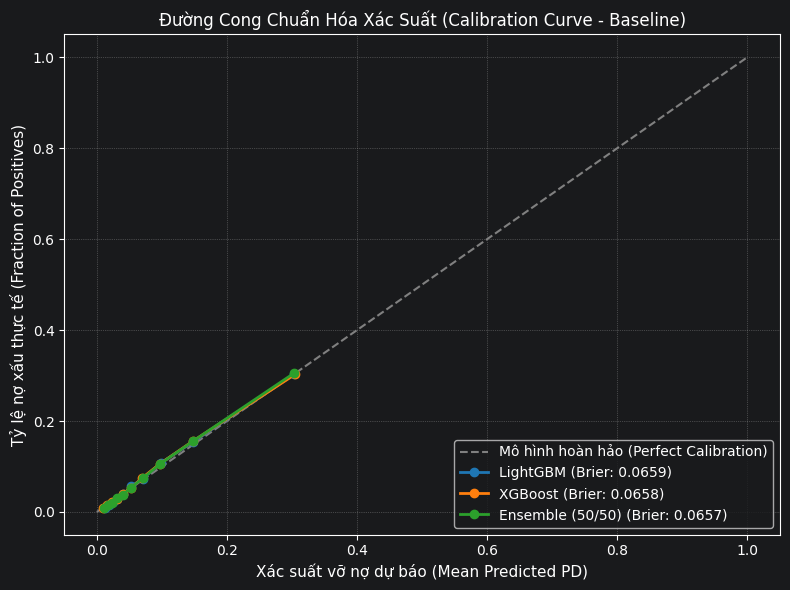

In [11]:
evaluate_models('/data/processed/master_train_dataset_v2.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v3.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78692 (Gap: +0.08143) | XGB Val: 0.78642 (Gap: +0.11344) | Ens Val: 0.78834 (Gap: +0.10060)
   ▫️ Fold 2 | LGB Val: 0.79481 (Gap: +0.07182) | XGB Val: 0.79589 (Gap: +0.10109) | Ens Val: 0.79727 (Gap: +0.08931)
   ▫️ Fold 3 | LGB Val: 0.78448 (Gap: +0.07388) | XGB Val: 0.78483 (Gap: +0.09900) | Ens Val: 0.78618 (Gap: +0.08872)
   ▫️ Fold 4 | LGB Val: 0.79317 (Gap: +0.08905) | XGB Val: 0.79260 (Gap: +0.10500) | Ens Val: 0.79462 (Gap: +0.09936)
   ▫️ Fold 5 | LGB Val: 0.78387 (Gap: +0.11052) | XGB Val: 0.78640 (Gap: +0.12023) | Ens Val: 0.78695 (Gap: +0.11746)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78859
🔹 XGBoost  : 0.78920
🥇 Ensemble : 0.79064

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78859,0.78865 ± 0.00451,0.87399,0.08534 ± 0.01398,57.72%,43.48%,0.06585
1,XGBoost,0.78920,0.78923 ± 0.00426,0.89698,0.10775 ± 0.00796,57.84%,43.63%,0.06578
2,Ensemble (50/50),0.79064,0.79067 ± 0.00444,0.88976,0.09909 ± 0.01042,58.13%,43.95%,0.06566



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,179.2 s,4.13 GB,0.0050 ms/sample
1,XGBoost,737.2 s,4.13 GB,0.0029 ms/sample
2,Ensemble (50/50),916.4 s,4.13 GB,0.0079 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 876 đặc trưng (cột) | Dung lượng trên RAM: 2080.2 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


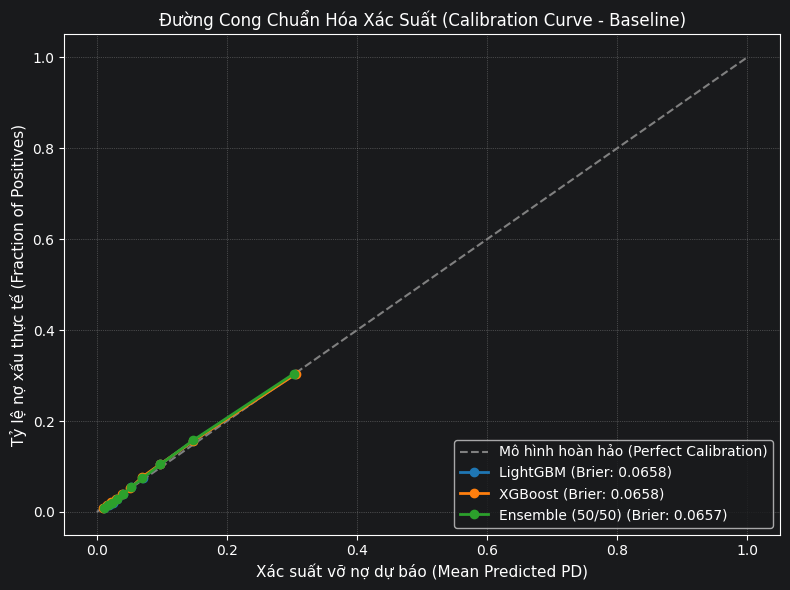

In [12]:
evaluate_models('/data/processed/master_train_dataset_v3.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78646 (Gap: +0.08209) | XGB Val: 0.78661 (Gap: +0.10634) | Ens Val: 0.78816 (Gap: +0.09674)
   ▫️ Fold 2 | LGB Val: 0.79533 (Gap: +0.09974) | XGB Val: 0.79551 (Gap: +0.10499) | Ens Val: 0.79741 (Gap: +0.10440)
   ▫️ Fold 3 | LGB Val: 0.78534 (Gap: +0.11796) | XGB Val: 0.78466 (Gap: +0.11334) | Ens Val: 0.78680 (Gap: +0.11802)
   ▫️ Fold 4 | LGB Val: 0.79298 (Gap: +0.06058) | XGB Val: 0.79212 (Gap: +0.11120) | Ens Val: 0.79445 (Gap: +0.09110)
   ▫️ Fold 5 | LGB Val: 0.78436 (Gap: +0.09100) | XGB Val: 0.78556 (Gap: +0.11849) | Ens Val: 0.78661 (Gap: +0.10772)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78883
🔹 XGBoost  : 0.78887
🥇 Ensemble : 0.79065

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78883,0.78889 ± 0.00441,0.87917,0.09028 ± 0.01900,57.77%,43.66%,0.06586
1,XGBoost,0.78887,0.78889 ± 0.00420,0.89976,0.11087 ± 0.00489,57.77%,43.70%,0.06582
2,Ensemble (50/50),0.79065,0.79069 ± 0.00442,0.89428,0.10360 ± 0.00926,58.13%,43.97%,0.06568



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,212.1 s,2.57 GB,0.0057 ms/sample
1,XGBoost,976.9 s,2.57 GB,0.0043 ms/sample
2,Ensemble (50/50),1189.0 s,2.57 GB,0.0100 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1041 đặc trưng (cột) | Dung lượng trên RAM: 2467.3 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


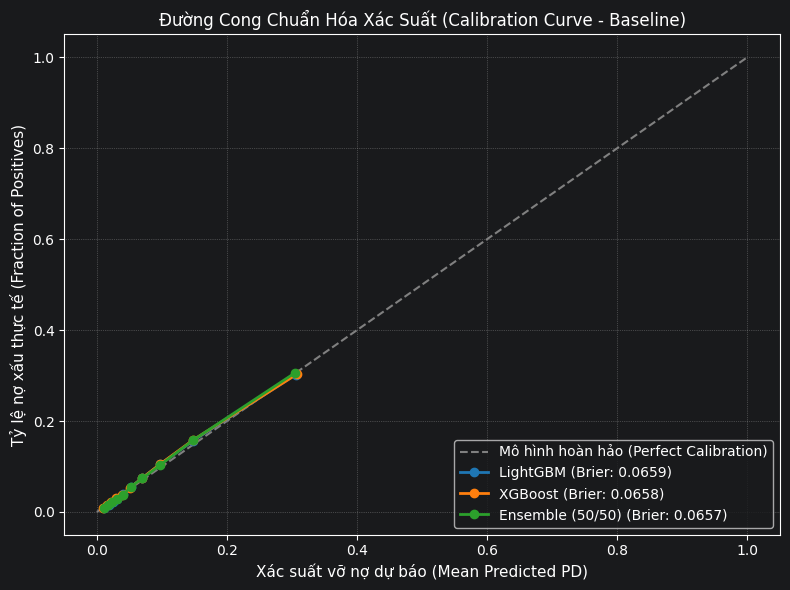

In [13]:
evaluate_models('/data/processed/master_train_dataset_v4.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78629 (Gap: +0.11133) | XGB Val: 0.78714 (Gap: +0.11966) | Ens Val: 0.78867 (Gap: +0.11752)
   ▫️ Fold 2 | LGB Val: 0.79512 (Gap: +0.07813) | XGB Val: 0.79655 (Gap: +0.10376) | Ens Val: 0.79778 (Gap: +0.09361)
   ▫️ Fold 3 | LGB Val: 0.78512 (Gap: +0.10137) | XGB Val: 0.78409 (Gap: +0.09336) | Ens Val: 0.78606 (Gap: +0.09988)
   ▫️ Fold 4 | LGB Val: 0.79362 (Gap: +0.08290) | XGB Val: 0.79271 (Gap: +0.10761) | Ens Val: 0.79506 (Gap: +0.09773)
   ▫️ Fold 5 | LGB Val: 0.78395 (Gap: +0.08934) | XGB Val: 0.78492 (Gap: +0.10686) | Ens Val: 0.78588 (Gap: +0.10047)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78876
🔹 XGBoost  : 0.78908
🥇 Ensemble : 0.79067

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%),Brier Score
0,LightGBM,0.78876,0.78882 ± 0.00462,0.88143,0.09261 ± 0.01218,57.75%,43.76%,0.06584
1,XGBoost,0.78908,0.78908 ± 0.00480,0.89533,0.10625 ± 0.00842,57.82%,43.80%,0.06581
2,Ensemble (50/50),0.79067,0.79069 ± 0.00486,0.89253,0.10184 ± 0.00820,58.13%,44.05%,0.06567



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,198.1 s,2.70 GB,0.0052 ms/sample
1,XGBoost,768.6 s,2.70 GB,0.0033 ms/sample
2,Ensemble (50/50),966.7 s,2.70 GB,0.0085 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 902 đặc trưng (cột) | Dung lượng trên RAM: 2141.2 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


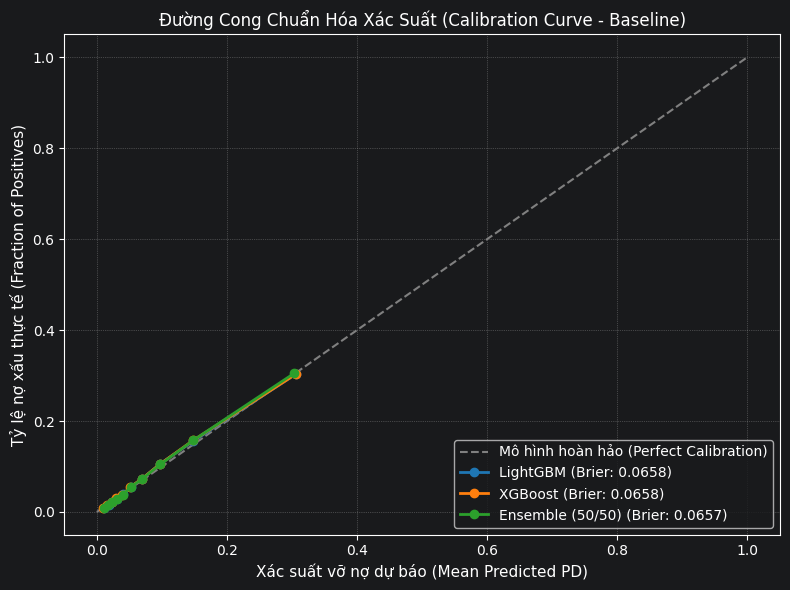

In [14]:
evaluate_models('/data/processed/master_train_dataset_v4_clean.parquet')


📂 [V2 OPTIMIZED] ĐÁNH GIÁ MÔ HÌNH VỚI BEST HYPERPARAMETERS: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation (Phiên bản V2 Tối Ưu)...
   ▫️ Fold 1 | LGB Val: 0.79093 (Gap: +0.11907) | XGB Val: 0.79124 (Gap: +0.08070)
   ▫️ Fold 2 | LGB Val: 0.80078 (Gap: +0.09704) | XGB Val: 0.79978 (Gap: +0.06387)
   ▫️ Fold 3 | LGB Val: 0.78869 (Gap: +0.10376) | XGB Val: 0.78880 (Gap: +0.08553)
   ▫️ Fold 4 | LGB Val: 0.79712 (Gap: +0.10263) | XGB Val: 0.79715 (Gap: +0.07182)
   ▫️ Fold 5 | LGB Val: 0.79003 (Gap: +0.10964) | XGB Val: 0.78944 (Gap: +0.08621)

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC V2 (OOF ROC-AUC)
🔹 LightGBM (Tuned)    : 0.79348
🔹 XGBoost (Tuned)     : 0.79324
🥇 Optimal Blend       : 0.79439
⚖️ Trọng số tối ưu     : LightGBM = 50.0% | XGBoost = 50.0%

📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG & ĐỘ CHUẨN XÁC XÁC SUẤT (V2 OPTIMIZED)


,Model,ROC-AUC (OOF),Fold AUC (Mean ± Std),Train AUC,Overfit Gap,Gini (%),KS (%),Brier Score
0,LightGBM (Tuned),0.79348,0.79351 ± 0.00464,0.89994,0.10643 ± 0.00748,58.70%,44.46%,0.06548
1,XGBoost (Tuned),0.79324,0.79328 ± 0.00439,0.87091,0.07762 ± 0.00859,58.65%,44.44%,0.06549
2,Optimal Blend (0.50/0.50),0.79439,0.79340 ± 0.00451,0.88542,0.09203 ± 0.00722,58.88%,44.59%,0.06539



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (V2 OPTIMIZED)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM (Tuned),614.5 s,2.51 GB,0.0136 ms/sample
1,XGBoost (Tuned),1684.8 s,2.51 GB,0.0072 ms/sample
2,Optimal Blend (0.50/0.50),2299.2 s,2.51 GB,0.0208 ms/sample



📌 Thông số tập dữ liệu: 307,511 dòng | 902 đặc trưng | RAM: 2141.2 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


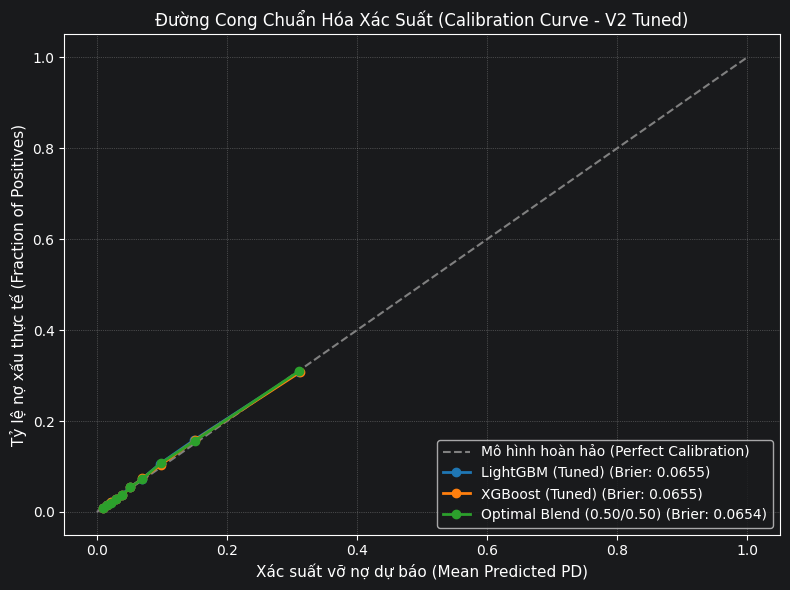

💾 Đã lưu cấu hình Ensemble & 10 Models vào: './saved_models_v2'


{'lgb_models': [LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsample=0.8906,
                 subsample_freq=1, verbose=-1),
  LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsample=0.8906,
                 subsample_freq=1, verbose=-1),
  LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsa

In [15]:
evaluate_models_v2_optimized('/data/processed/master_train_dataset_v4_clean.parquet')

📂 [V2 OPTIMIZED] ĐÁNH GIÁ MÔ HÌNH VỚI BEST HYPERPARAMETERS: /Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet
⚡ Đang chạy 5-Fold Cross Validation (Phiên bản V2 Tối Ưu)...
   ▫️ Fold 1 | LGB Val: 0.78967 (Gap: +0.09339) | XGB Val: 0.79026 (Gap: +0.07450)
   ▫️ Fold 2 | LGB Val: 0.79799 (Gap: +0.09811) | XGB Val: 0.79761 (Gap: +0.06465)
   ▫️ Fold 3 | LGB Val: 0.78674 (Gap: +0.08521) | XGB Val: 0.78616 (Gap: +0.08394)
   ▫️ Fold 4 | LGB Val: 0.79451 (Gap: +0.10900) | XGB Val: 0.79523 (Gap: +0.06779)
   ▫️ Fold 5 | LGB Val: 0.78698 (Gap: +0.11053) | XGB Val: 0.78760 (Gap: +0.08463)

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC V2 (OOF ROC-AUC)
🔹 LightGBM (Tuned)    : 0.79116
🔹 XGBoost (Tuned)     : 0.79133
🥇 Optimal Blend       : 0.79226
⚖️ Trọng số tối ưu     : LightGBM = 50.0% | XGBoost = 50.0%

📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG & ĐỘ CHUẨN XÁC XÁC SUẤT (V2 OPTIMIZED)


,Model,ROC-AUC (OOF),Fold AUC (Mean ± Std),Train AUC,Overfit Gap,Gini (%),KS (%),Brier Score
0,LightGBM (Tuned),0.79116,0.79118 ± 0.00441,0.89043,0.09925 ± 0.00954,58.23%,44.13%,0.06563
1,XGBoost (Tuned),0.79133,0.79137 ± 0.00439,0.86647,0.07510 ± 0.00815,58.27%,44.25%,0.06558
2,Optimal Blend (0.50/0.50),0.79226,0.79127 ± 0.00439,0.87845,0.08718 ± 0.00567,58.45%,44.33%,0.06552



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (V2 OPTIMIZED)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM (Tuned),547.8 s,2.80 GB,0.0129 ms/sample
1,XGBoost (Tuned),1527.8 s,2.80 GB,0.0059 ms/sample
2,Optimal Blend (0.50/0.50),2075.6 s,2.80 GB,0.0188 ms/sample



📌 Thông số tập dữ liệu: 307,511 dòng | 891 đặc trưng | RAM: 2112.3 MB

📈 Đang hiển thị biểu đồ Calibration Curve...


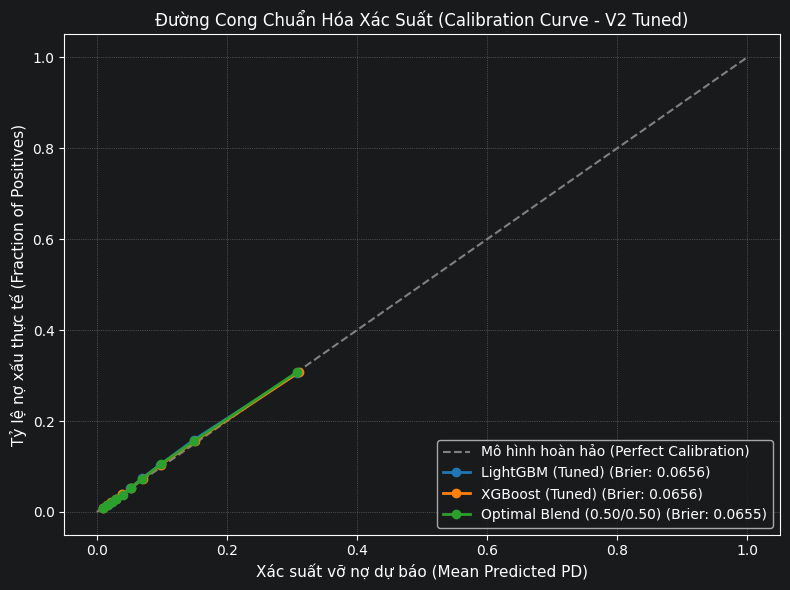

💾 Đã lưu cấu hình Ensemble & 10 Models vào: '/Users/nguyenminhtri/FinalYearPro/notebook/Model/fair'


{'lgb_models': [LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsample=0.8906,
                 subsample_freq=1, verbose=-1),
  LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsample=0.8906,
                 subsample_freq=1, verbose=-1),
  LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsa

In [21]:
evaluate_models_v2_optimized('/data/processed/df_train_fair_compliant.parquet')

In [26]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_shap_workbench(trained_model, X_sample, customer_idx=0, top_n=20):
    """
    Hàm tất-cả-trong-một:
    - Vẽ 2 phương án biểu đồ Global SHAP thay thế Beeswarm.
    - Phân tích chi tiết hồ sơ cá nhân của khách hàng tại dòng `customer_idx`.
    """
    print("⏳ Đang khởi tạo TreeExplainer và tính toán SHAP values...")
    explainer = shap.TreeExplainer(trained_model)
    shap_values = explainer.shap_values(X_sample)

    # Đối với bài toán nhị phân, LightGBM thường trả về list [shap_class_0, shap_class_1] hoặc mảng 2D
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

    feature_names = list(X_sample.columns)

    # =========================================================================
    # PHẦN 1: SO SÁNH 2 BIỂU ĐỒ GLOBAL (THAY THẾ BEESWARM)
    # =========================================================================
    print(f"\n📊 Đang vẽ 2 phương án biểu đồ Global Importance cho Top {top_n} biến...")
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    # --- PHƯƠNG ÁN 1: Mean Absolute Bar Plot ---
    mean_abs = np.mean(np.abs(shap_vals), axis=0)
    top_indices_1 = np.argsort(mean_abs)[-top_n:]

    y_pos1 = np.arange(top_n)
    axes[0].barh(y_pos1, mean_abs[top_indices_1], color='#1f77b4', edgecolor='black', alpha=0.85)
    axes[0].set_yticks(y_pos1)
    axes[0].set_yticklabels([feature_names[i] for i in top_indices_1], fontsize=10)
    axes[0].set_xlabel('Mean |SHAP Value| (Mức độ tác động tuyệt đối)', fontsize=11, fontweight='bold')
    axes[0].set_title('PHƯƠNG ÁN 1: Mean Absolute Bar Plot\n(Gọn gàng, chuẩn mực báo cáo kỹ thuật)', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', linestyle=':', alpha=0.6)

    # --- PHƯƠNG ÁN 2: Positive vs. Negative Impact Bar Plot ---
    pos_impact = np.mean(np.maximum(shap_vals, 0), axis=0)
    neg_impact = np.mean(np.minimum(shap_vals, 0), axis=0)
    total_impact = pos_impact + np.abs(neg_impact)
    top_indices_2 = np.argsort(total_impact)[-top_n:]

    y_pos2 = np.arange(top_n)
    axes[1].barh(y_pos2, pos_impact[top_indices_2], color='#d62728', alpha=0.85, edgecolor='black', label='Đẩy rủi ro tăng (+PD)')
    axes[1].barh(y_pos2, neg_impact[top_indices_2], color='#2ca02c', alpha=0.85, edgecolor='black', label='Kéo rủi ro giảm (-PD)')
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_yticks(y_pos2)
    axes[1].set_yticklabels([feature_names[i] for i in top_indices_2], fontsize=10)
    axes[1].set_xlabel('Mean Impact on Model Output (Chiều tác động)', fontsize=11, fontweight='bold')
    axes[1].set_title('PHƯƠNG ÁN 2: Positive vs. Negative Decomposition\n(Thấy rõ biến nào chuyên làm tăng/giảm rủi ro)', fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=10)
    axes[1].grid(axis='x', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PHẦN 2: BÓC TÁCH HỒ SƠ CÁ NHÂN (LOCAL EXPLANATION)
    # =========================================================================
    row_shap = shap_vals[customer_idx]
    row_data = X_sample.iloc[customer_idx]

    df_local = pd.DataFrame({
        'Feature': feature_names,
        'Value': row_data.values,
        'SHAP_Impact': row_shap
    })

    # Tách top 5 lý do làm tăng rủi ro và top 5 lý do kéo giảm rủi ro
    df_risk_up = df_local[df_local['SHAP_Impact'] > 0].sort_values(by='SHAP_Impact', ascending=False).head(5)
    df_risk_down = df_local[df_local['SHAP_Impact'] < 0].sort_values(by='SHAP_Impact', ascending=True).head(5)

    print("=" * 80)
    print(f"📋 PHÂN TÍCH HỒ SƠ KHÁCH HÀNG (Dòng index: {customer_idx})")
    print("=" * 80)

    print("\n🔴 [TOP 5 YẾU TỐ LÀM TĂNG RỦI RƠ - REASON CODES TỪ CHỐI]:")
    print(df_risk_up.to_string(index=False))

    print("\n🟢 [TOP 5 ĐIỂM TÍCH CỰC - YẾU TỐ BẢO VỆ GIẢM RỦI RO]:")
    print(df_risk_down.to_string(index=False))
    print("=" * 80)

    return {
        'explainer': explainer,
        'shap_values': shap_vals,
        'customer_risk_up': df_risk_up,
        'customer_risk_down': df_risk_down
    }

✅ Đã nạp thành công model từ: /Users/nguyenminhtri/FinalYearPro/notebook/Model/fair/lgb_model_fold_1.joblib
⏳ Đang khởi tạo TreeExplainer và tính toán SHAP values...

📊 Đang vẽ 2 phương án biểu đồ Global Importance cho Top 20 biến...


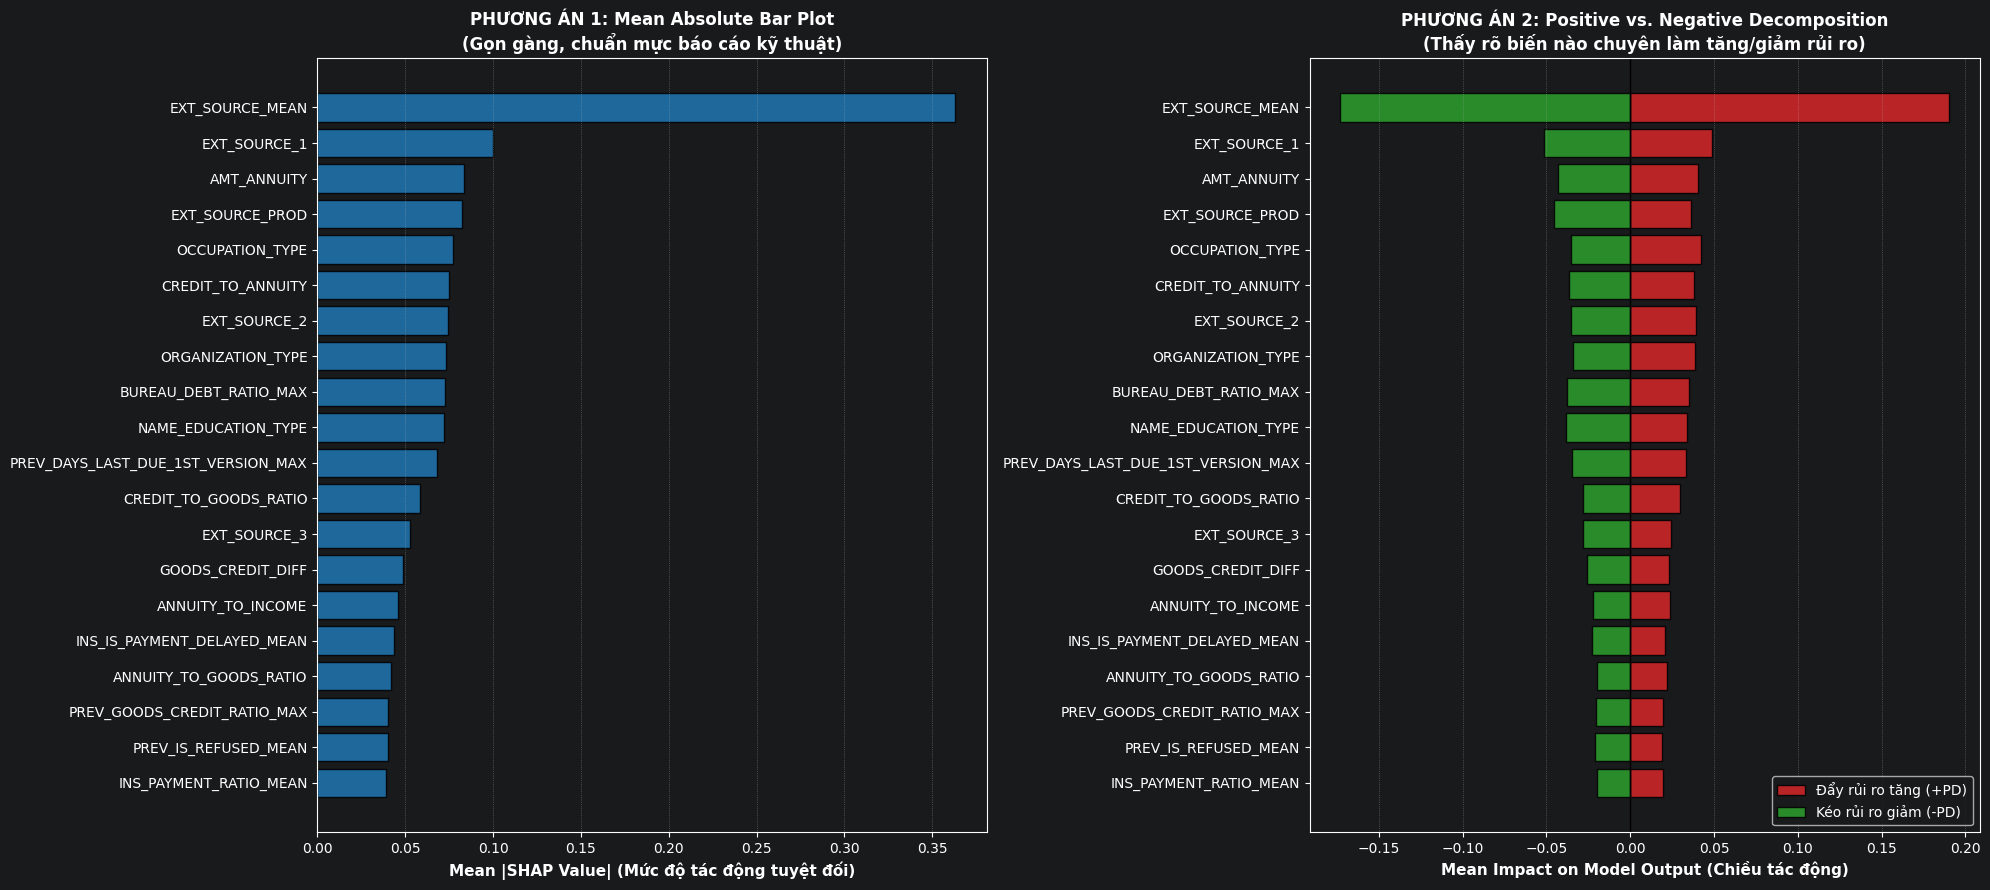

📋 PHÂN TÍCH HỒ SƠ KHÁCH HÀNG (Dòng index: 0)

🔴 [TOP 5 YẾU TỐ LÀM TĂNG RỦI RƠ - REASON CODES TỪ CHỐI]:
             Feature     Value  SHAP_Impact
     EXT_SOURCE_PROD  0.000216     0.247647
     EXT_SOURCE_MEAN    0.4271     0.243698
PREV_IS_REFUSED_MEAN       0.6     0.135169
         AMT_ANNUITY   52641.0     0.130511
   ANNUITY_TO_INCOME  0.254304     0.072622

🟢 [TOP 5 ĐIỂM TÍCH CỰC - YẾU TỐ BẢO VỆ GIẢM RỦI RO]:
                     Feature              Value  SHAP_Impact
                EXT_SOURCE_1           0.675878    -0.169358
       BUREAU_DEBT_RATIO_MAX           0.683922    -0.111371
           CREDIT_TO_ANNUITY            8.84211    -0.096474
PREV_GOODS_CREDIT_RATIO_MEAN  7650000000.625384    -0.085414
BUREAU_ACTIVE_DEBT_RATIO_MAX           0.683922    -0.074028


In [28]:
import os
import json
import joblib
import pandas as pd

# 1. Đường dẫn thư mục chứa artifacts đã lưu
artifact_dir = "/Model/fair"

# 2. Đọc file config để lấy đúng danh sách cột feature
config_path = os.path.join(artifact_dir, "blend_config_v2.json")
with open(config_path, "r", encoding="utf-8") as f:
    blend_config = json.load(f)

# 3. Load trực tiếp model LightGBM Fold 1 từ đĩa (thay thế cho results['lgb_models'][0])
model_path = os.path.join(artifact_dir, "lgb_model_fold_1.joblib")
model_to_explain = joblib.load(model_path)
print(f"✅ Đã nạp thành công model từ: {model_path}")

# 4. Chuẩn bị tập dữ liệu mẫu và chuẩn hóa kiểu dữ liệu
df_eval = pd.read_parquet('/data/processed/df_train_fair_compliant.parquet')
X_eval = df_eval[blend_config['feature_names']].copy()

cat_cols = X_eval.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X_eval[col] = X_eval[col].astype('category')

sample_X = X_eval.sample(n=1000, random_state=42)

# 5. Chạy hàm SHAP workbench
shap_results = run_shap_workbench(
    trained_model=model_to_explain,
    X_sample=sample_X,
    customer_idx=0,
    top_n=20
)

In [29]:
import os
import json
import pandas as pd

# 1. Đường dẫn tới tập train sạch đã được xử lý (đã dùng để train model)
train_path = "/Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet"
if not os.path.exists(train_path):
    # Đường dẫn dự phòng nếu bạn lưu ở data/preprocess/
    train_path = "/Users/nguyenminhtri/FinalYearPro/data/preprocess/df_main_clean.parquet"

print(f"🔄 Đang nạp dữ liệu train từ: {train_path}")
df_train = pd.read_parquet(train_path)

# 2. Rút các giá trị phân vị và mức trung bình nhóm chuẩn mực từ tập Train
benchmarks = {
    # Ngưỡng chặn ngoại lai 99.9% của thu nhập
    "income_cap_999": float(df_train["AMT_INCOME_TOTAL"].quantile(0.999)),
    # Giá trị trung vị để điền khuyết cho AMT_ANNUITY
    "annuity_median": float(df_train["AMT_ANNUITY"].median()),
    # Mức trung bình thu nhập theo nhóm ngành nghề (OCCUPATION_TYPE)
    "occ_income_means": {
        str(k): float(v)
        for k, v in df_train.groupby("OCCUPATION_TYPE")["AMT_INCOME_TOTAL"]
        .mean()
        .items()
    },
    # Mức trung bình thu nhập theo trình độ học vấn (NAME_EDUCATION_TYPE)
    "edu_income_means": {
        str(k): float(v)
        for k, v in df_train.groupby("NAME_EDUCATION_TYPE")[
            "AMT_INCOME_TOTAL"
        ]
        .mean()
        .items()
    },
    # Mức trung bình thu nhập theo loại hình thu nhập (NAME_INCOME_TYPE)
    "inc_type_income_means": {
        str(k): float(v)
        for k, v in df_train.groupby("NAME_INCOME_TYPE")["AMT_INCOME_TOTAL"]
        .mean()
        .items()
    },
}

# 3. Lưu thành file cấu hình chuẩn train_benchmarks.json
output_dir = "/Users/nguyenminhtri/FinalYearPro/Model/fair"
os.makedirs(output_dir, exist_ok=True)
benchmark_file = os.path.join(output_dir, "train_benchmarks.json")

with open(benchmark_file, "w", encoding="utf-8") as f:
    json.dump(benchmarks, f, indent=4, ensure_ascii=False)

print("=" * 60)
print(f"✅ ĐÃ TRÍCH XUẤT VÀ LƯU THÀNH CÔNG TẠI: {benchmark_file}")
print(f"   • Ngưỡng chặn thu nhập 99.9%: {benchmarks['income_cap_999']:,.2f}")
print(f"   • Trung vị tiền trả định kỳ: {benchmarks['annuity_median']:,.2f}")
print(f"   • Số ngành nghề được lập benchmark: {len(benchmarks['occ_income_means'])}")
print("=" * 60)


🔄 Đang nạp dữ liệu train từ: /Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet
✅ ĐÃ TRÍCH XUẤT VÀ LƯU THÀNH CÔNG TẠI: /Users/nguyenminhtri/FinalYearPro/Model/fair/train_benchmarks.json
   • Ngưỡng chặn thu nhập 99.9%: 900,000.00
   • Trung vị tiền trả định kỳ: 24,903.00
   • Số ngành nghề được lập benchmark: 19


In [33]:
import os
import json
import shutil
import pandas as pd

# 1. Thư mục đích: src/models/
target_model_dir = '/Users/nguyenminhtri/FinalYearPro/src/models'
os.makedirs(target_model_dir, exist_ok=True)

config_path = os.path.join(target_model_dir, 'blend_config_v2.json')
old_config_path = '/Users/nguyenminhtri/FinalYearPro/Model/fair/blend_config_v2.json'
output_schema_path = os.path.join(target_model_dir, 'feature_metadata.json')

# Tự động đồng bộ blend_config_v2.json vào src/models/ nếu chưa có
if not os.path.exists(config_path):
    if os.path.exists(old_config_path):
        print(f"🔄 Đang copy blend_config_v2.json sang {target_model_dir}...")
        shutil.copy(old_config_path, config_path)
    else:
        raise FileNotFoundError(f"❌ Không tìm thấy blend_config_v2.json tại: {config_path} hoặc {old_config_path}")

# 2. Đọc trực tiếp file train fair compliant từ data/processed/
train_fair_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet'

if not os.path.exists(train_fair_path):
    raise FileNotFoundError(f"❌ Không tìm thấy tệp tại: {train_fair_path}")

print(f"📖 Đang đọc tập train fair compliant từ: {train_fair_path}")
df_train = pd.read_parquet(train_fair_path)
print(f"   • Kích thước: {df_train.shape[0]:,} dòng | {df_train.shape[1]} cột")

# 3. Đọc danh sách biến chính thức của Model
with open(config_path, 'r', encoding='utf-8') as f:
    config = json.load(f)
model_features = config['feature_names']

# 4. Khóa cứng kiểu dữ liệu & bảng ánh xạ 2 chiều
metadata = {
    "dtypes": {},
    "categorical_mappings": {}
}

for col in model_features:
    if col not in df_train.columns:
        continue

    is_cat = (df_train[col].dtype == 'object') or isinstance(df_train[col].dtype, pd.CategoricalDtype)
    metadata["dtypes"][col] = "category" if is_cat else str(df_train[col].dtype)

    if is_cat:
        unique_vals = sorted([str(val) for val in df_train[col].dropna().unique()])
        metadata["categorical_mappings"][col] = {
            "label_to_code": {val: idx for idx, val in enumerate(unique_vals)},
            "code_to_label": {str(idx): val for idx, val in enumerate(unique_vals)}
        }

# 5. Lưu file feature_metadata.json trực tiếp vào src/models/
with open(output_schema_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("=" * 70)
print(f"🎉 ĐÃ TẠO THÀNH CÔNG: {output_schema_path}")
print(f"   • Số cột định dạng kiểu: {len(metadata['dtypes'])}")
print(f"   • Số cột phân loại có từ điển 2 chiều: {len(metadata['categorical_mappings'])}")
print("=" * 70)


📖 Đang đọc tập train fair compliant từ: /Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet
   • Kích thước: 307,511 dòng | 893 cột
🎉 ĐÃ TẠO THÀNH CÔNG: /Users/nguyenminhtri/FinalYearPro/src/models/feature_metadata.json
   • Số cột định dạng kiểu: 891
   • Số cột phân loại có từ điển 2 chiều: 0


In [34]:
import os
import json
import numpy as np
import pandas as pd

# 1. Đường dẫn các file cấu hình và dữ liệu train
metadata_path = '/Users/nguyenminhtri/FinalYearPro/src/models/feature_metadata.json'
train_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet'
config_path = '/Users/nguyenminhtri/FinalYearPro/src/models/blend_config_v2.json'

print(f"📖 Nạp dữ liệu train chuẩn: {train_path}")
df_train = pd.read_parquet(train_path)

with open(config_path, 'r', encoding='utf-8') as f:
    blend_cfg = json.load(f)
target_features = blend_cfg['feature_names']

# 2. Khởi tạo cấu trúc metadata đa tầng
full_metadata = {
    "system_info": {
        "version": "v2.0-fair",
        "total_features": len(target_features),
        "unseen_fallback_label": "Missing"
    },
    "dtypes": {},
    "categorical_mappings": {},
    "numeric_ranges": {}
}

# 3. Phân loại và xây dựng metadata cho từng biến
for col in target_features:
    if col not in df_train.columns:
        continue

    s = df_train[col]

    # Kiểm tra biến phân loại (chuỗi hoặc category)
    is_cat = (s.dtype in ['object', 'string', 'category']) or (s.dtype == 'str')

    if is_cat:
        full_metadata["dtypes"][col] = "category"

        # Trích xuất danh sách giá trị độc nhất, loại bỏ rác/NaN
        raw_uniques = [str(x).strip() for x in s.dropna().unique() if str(x).strip() not in ['', 'nan', 'NaN']]
        valid_uniques = sorted(list(set(raw_uniques)))

        # Bổ sung nhãn an toàn cho trường hợp thiếu/lạ
        if "Missing" not in valid_uniques:
            valid_uniques.append("Missing")

        label_to_code = {label: idx for idx, label in enumerate(valid_uniques)}
        code_to_label = {str(idx): label for idx, label in enumerate(valid_uniques)}

        full_metadata["categorical_mappings"][col] = {
            "valid_labels": valid_uniques,
            "label_to_code": label_to_code,
            "code_to_label": code_to_label,
            "fallback_code": label_to_code["Missing"]
        }
    else:
        # Biến định lượng số (Float/Int)
        full_metadata["dtypes"][col] = str(s.dtype)

        s_clean = s.dropna()
        if not s_clean.empty:
            full_metadata["numeric_ranges"][col] = {
                "min": float(np.round(s_clean.min(), 4)),
                "max": float(np.round(s_clean.max(), 4)),
                "median": float(np.round(s_clean.median(), 4)),
                "p5": float(np.round(s_clean.quantile(0.05), 4)),
                "p95": float(np.round(s_clean.quantile(0.95), 4))
            }

# 4. Ghi đè vào file metadata chính thức
os.makedirs(os.path.dirname(metadata_path), exist_ok=True)
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(full_metadata, f, indent=4, ensure_ascii=False)

print("=" * 80)
print(f"🎉 CẬP NHẬT HOÀN TẤT FEATURE METADATA CONTRACT")
print(f"👉 File đã lưu tại: {metadata_path}")
print(f" • Tổng số biến đăng ký           : {len(full_metadata['dtypes'])}")
print(f" • Biến phân loại (Categorical)    : {len(full_metadata['categorical_mappings'])} cột")
print(f" • Biến số học (Numeric Ranges)    : {len(full_metadata['numeric_ranges'])} cột")
print("=" * 80)

📖 Nạp dữ liệu train chuẩn: /Users/nguyenminhtri/FinalYearPro/data/processed/df_train_fair_compliant.parquet
🎉 CẬP NHẬT HOÀN TẤT FEATURE METADATA CONTRACT
👉 File đã lưu tại: /Users/nguyenminhtri/FinalYearPro/src/models/feature_metadata.json
 • Tổng số biến đăng ký           : 891
 • Biến phân loại (Categorical)    : 4 cột
 • Biến số học (Numeric Ranges)    : 887 cột
